# Household Behavior over the Life Cycle Exam 2025.
## Setup and Model Economy

We will study the portfolio allocation of individuals throughout their
lives. Baseline code is available through Digital Exam. In each period,
individuals choose how much to consume, $c_{t}$, and how to allocate
resources between a riskless asset, $a_{t}$, that earns a guaranteed
gross return of $R^{a}$ between period $t$ and $t+1$ and a risky
asset, $b_{t}$, that earns a stochastic gross return of $R_{t+1}^{b}$
between period $t$ to $t+1$, following an AR(1) process. The share
in the risky asset is denoted $x_{t}$. In each period, households
earn a deterministic income of $y_{t}$. The state variables are the
total amount of savings, $s_{t}=a_{t}+b_{t}\in\mathbb{R}_{+}$ and
the current gross return on the risky asset, $R_{t}^{b}\in\mathbb{R}_{+}$.
Consumers are not allowed to borrow such that post-consumption resources
must be non-negative, $w_{t}=s_{t}+y_{t}-c_{t}\geq0$, and $x_{t}$
must lie in the unit interval, $x_{t}\in[0,1]$.

The recursive formulation (Bellman equation) for the model is, for
$1\leq t<T$,
\begin{align}
V_{t}(s_{t},R_{t}^{b}) & =\max_{c_{t},x_{t}}U(c_{t})+\beta\mathbb{E}_{t}[V_{t+1}(s_{t+1},R_{t+1}^{b})]\\
 & \text{s.t.}\nonumber \\
s_{t+1} & =a_{t+1}+b_{t+1}\\
a_{t+1} & =R^{a}(1-x_{t})w_{t}\\
b_{t+1} & =R_{t+1}^{b}x_{t}w_{t}\\
R_{t+1}^{b} & =\begin{cases}
\begin{array}{ll}
R_{t}^{b}+\varepsilon_{t} & \text{if }R_{t}^{b}+\varepsilon_{t}>0\\
0 & \text{else}
\end{array}\end{cases}\\
\varepsilon_{t} & \sim iid\mathcal{N}(0,\sigma^{2})\\
w_{t} & =s_{t}+y_{t}-c_{t}\\
c_{t} & \in(0,s_{t}+y_{t}]\\
x_{t} & \in[0,1]
\end{align}
where preferences are Constant Relative Risk Aversion (CRRA),
\begin{equation}
U(c_{t})=\frac{c_{t}^{1-\rho}}{1-\rho}.
\end{equation}
There is no bequest motive such that for $t=T$,
\begin{align}
V_{T}(s_{T},R_{T}^{b}) & =\max_{c_{T}}U(c_{T})\\
 & \text{s.t.}\nonumber \\
0 & \leq s_{T}+y_{T}-c_{T}.
\end{align}
Since there is no portfolio allocation choice in the last period of life, we set it to zero for all states in period $T$ on line 116 in `PortfolioModel.py`.

The baseline parameters are $T=10$, $\beta=0.98$, $\rho=2.0$, $R^{a}=1.01$,
$y_{t}=1\:\forall t$ and $\sigma^{2}=0.03$. When simulating, we
draw initial levels of all state variables in the following way: Initial
savings are drawn from a uniform distribution on the interval $[0.5,1.5]$,
$s_{i,1}\sim U(0.5,1.5)$, and the initial level of risky returns
are $R_{i,1}=R^{a}+0.02$ for all individuals and they then face individual-specific
return shocks, $\varepsilon_{i,t}$, throughout their lives. We thus
think of the risky asset as individual-specific assets that follows
the same distribution but might experience different shocks. We simulate
$N=5,000$ individuals for $T=10$ periods. Questions can be answered
independently but the idea is that you answer question $j$ building
on the setup in question $j-1$. Try to avoid copy-pasting code but
rather generate one code base that can answer all questions. 

## Setup and load packages

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy.optimize import minimize, minimize_scalar, root_scalar
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

## Example: setup model instance, solve and simulate it.

In [2]:
from PortfolioModel import PortfolioModelClass
model = PortfolioModelClass()

%time model.solve()
%time model.simulate()

CPU times: user 1min 15s, sys: 57.6 s, total: 2min 12s
Wall time: 22.8 s
CPU times: user 1.11 s, sys: 871 ms, total: 1.98 s
Wall time: 445 ms


## Q3: Solve and simulate the baseline model. Also solve and simulate a no-risk version of the model.

In [3]:
# baseline (with risk)
model = PortfolioModelClass()
model.solve()
model.simulate()

# no-risk version: switch off risky-return uncertainty via sigma2 = 0
model_norisk = PortfolioModelClass(par={'sigma2':0.0})
model_norisk.solve()
model_norisk.simulate()

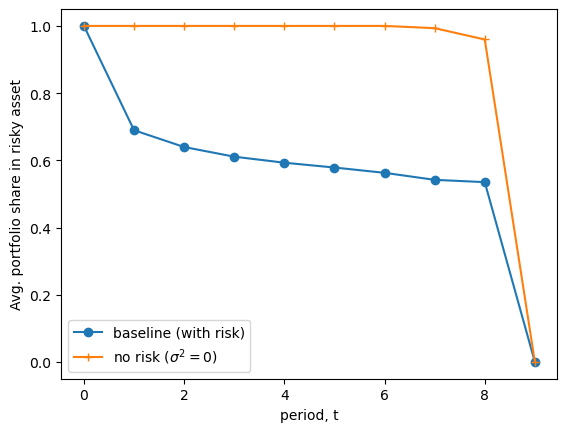

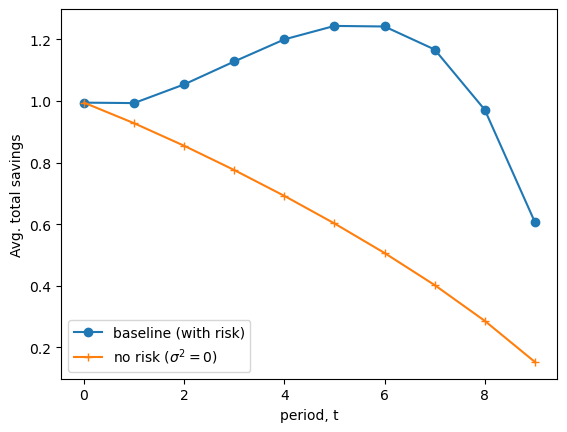

In [5]:
labels = {'x':'portfolio share in risky asset', 's':'total savings',
          'c':'consumption', 'Rb':'risky return'}
age = range(model.par.simT)

for val in ('x','s'):
    fig, ax = plt.subplots()
    ax.plot(age, np.nanmean(getattr(model.sim,        val), axis=0), label='baseline (with risk)', marker='o')
    ax.plot(age, np.nanmean(getattr(model_norisk.sim, val), axis=0), label='no risk ($\sigma^2=0$)',              marker='+')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='period, t')
    ax.legend()

## Q4: 


/var/folders/ch/svk174ms2t7404n3sl5_kg380000gn/T/ipykernel_61709/2943574686.py:7: RuntimeWarning: Mean of empty slice
  ax.plot(age, np.nanmean(model.sim.R, axis=0), marker='o')


[Text(0, 0.5, 'Avg. realized portfolio return'), Text(0.5, 0, 'period, t')]

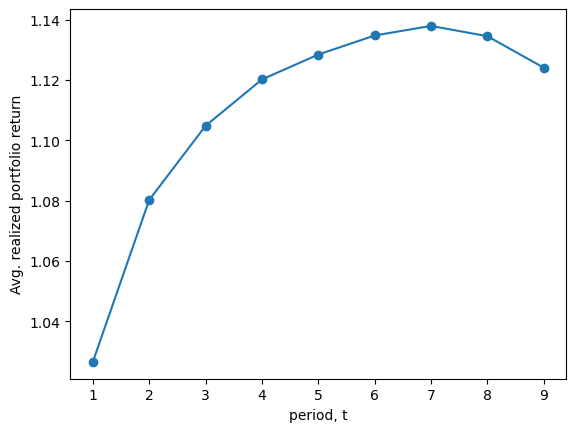

In [6]:
model = PortfolioModelClass()
model.solve()
model.simulate()

age = range(model.par.simT)
fig, ax = plt.subplots()
ax.plot(age, np.nanmean(model.sim.R, axis=0), marker='o')
ax.set(ylabel='Avg. realized portfolio return', xlabel='period, t')

In [7]:
import numpy as np

sT = model.sim.s[:,-1]   # s_{i,T}: total savings in the final period (code index 9 = exam period T)
R2 = model.sim.R[:,1]    # R_{i,2}: realized return in period two (we stored it at t+1, so index 1)

corr = np.corrcoef(sT, R2)[0,1]
print(f'corr(s_T, R_2) = {corr:.3f}')

corr(s_T, R_2) = 0.476


In [8]:
model_eq = PortfolioModelClass()
model_eq.solve()                  # solve() doesn't depend on initial wealth, so solve once
model_eq.sim.init_s[:] = 1.0      # everyone starts with s_1 = 1
model_eq.simulate()

sT_eq = model_eq.sim.s[:,-1]
R2_eq = model_eq.sim.R[:,1]
corr_eq = np.corrcoef(sT_eq, R2_eq)[0,1]
print(f'corr (equal start, s_1=1) = {corr_eq:.3f}')

corr (equal start, s_1=1) = 0.482


## Q6: Add capital gains tax


/var/folders/ch/svk174ms2t7404n3sl5_kg380000gn/T/ipykernel_61709/525570811.py:13: RuntimeWarning: Mean of empty slice
  ax.plot(age, np.nanmean(getattr(model.sim,     val), axis=0), label='no tax',            marker='o')
/var/folders/ch/svk174ms2t7404n3sl5_kg380000gn/T/ipykernel_61709/525570811.py:14: RuntimeWarning: Mean of empty slice
  ax.plot(age, np.nanmean(getattr(model_tax.sim, val), axis=0), label='capital gains tax', marker='+')


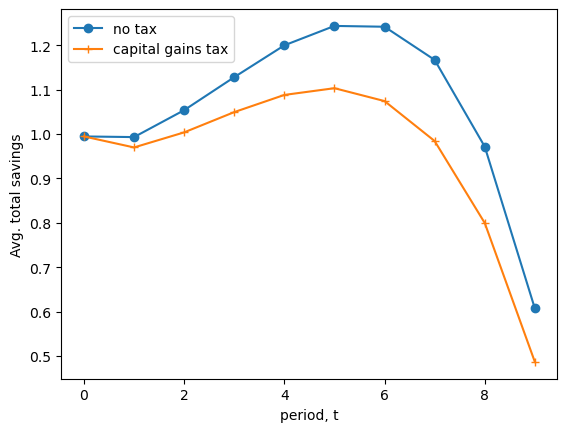

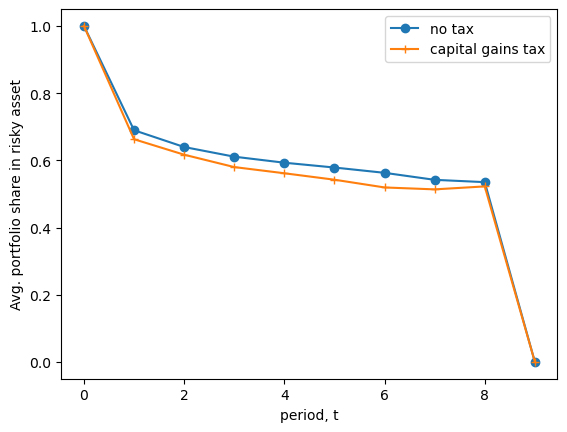

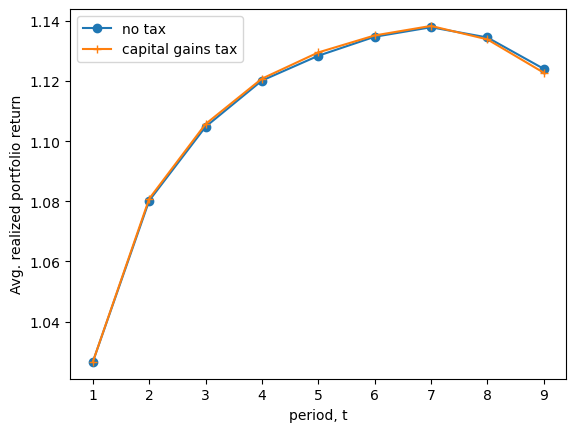

In [11]:
from PortfolioModel import PortfolioModelClass

model_tax = PortfolioModelClass(par={'tau':0.15})
model_tax.solve()
model_tax.simulate()

labels = {'s':'total savings', 'x':'portfolio share in risky asset',
          'R':'realized portfolio return'}
age = range(model.par.simT)

for val in ('s','x','R'):
    fig, ax = plt.subplots()
    ax.plot(age, np.nanmean(getattr(model.sim,     val), axis=0), label='no tax',            marker='o')
    ax.plot(age, np.nanmean(getattr(model_tax.sim, val), axis=0), label='capital gains tax', marker='+')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='period, t')
    ax.legend()

In [12]:
final_s_tax = model_tax.sim.s[:,-1]
returnR_tax = model_tax.sim.R[:,1]
print(f'The correlation is now {np.corrcoef(returnR_tax,final_s_tax)[0,1]:2.3f}')
print(f'suggesting that the tax itself did not change the link significantly. \nThe gained tax revenue could, however, be used to re-distribute to consumers with fewer resources.')

The correlation is now 0.486
suggesting that the tax itself did not change the link significantly. 
The gained tax revenue could, however, be used to re-distribute to consumers with fewer resources.
